# ANN-UTADIS for preference learning

In [7]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

cwd = Path.cwd()
project_root = cwd if (cwd / "data").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.ann_utadis import (
    AnnUtadis,
    PreferenceMinMaxScaler,
    create_dataloaders,
    predict_ann_utadis,
    save_ann_utadis_bundle,
    train_ann_utadis,
)
from src.metrics import evaluate_model

## Load hospital data and binarize target
Binary target:
- 1 = good hospital (`hospital_overall_rating >= 4`)
- 0 = bad hospital

In [8]:
data_path = project_root / "data" / "hospital_data.csv"
df = pd.read_csv(data_path)

cost_cols = [
    "mort_ami",
    "comp_hip_knee",
    "readmission_hf",
    "spending",
    "count_of_readm_measures_worse",
]
gain_cols = ["count_of_safety_measures_better"]
feature_cols = cost_cols + gain_cols

model_df = df.copy()

model_df["target"] = (model_df["hospital_overall_rating"] >= 4).astype(int)

X = model_df[feature_cols]
y = model_df["target"]

print("Rows:", len(model_df))
print("Class balance:")
print(y.value_counts(normalize=True).rename("share").round(4))

Rows: 500
Class balance:
target
0    0.602
1    0.398
Name: share, dtype: float64


## Split train/test and normalize criteria to [0, 1]
For normalization, 1 means the most preferred value and 0 the least preferred.

In [9]:
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = PreferenceMinMaxScaler(gain_columns=gain_cols, cost_columns=cost_cols)
X_train_norm = scaler.fit_transform(X_train_df)
X_test_norm = scaler.transform(X_test_df)

# Sanity check: all criteria are in [0, 1]
print("Train min:", float(X_train_norm.min().min()), "Train max:", float(X_train_norm.max().max()))
print("Test min:", float(X_test_norm.min().min()), "Test max:", float(X_test_norm.max().max()))
print("Train shape:", X_train_norm.shape, "Test shape:", X_test_norm.shape)

Train min: 0.0 Train max: 1.0
Test min: 0.0 Test max: 1.0
Train shape: (400, 6) Test shape: (100, 6)


## Initialize and train ANN-UTADIS

In [10]:
train_loader, test_loader = create_dataloaders(
    X_train_norm.values,
    y_train.values,
    X_test_norm.values,
    y_test.values,
    batch_size=None,
)

model = AnnUtadis(
    num_criteria=len(feature_cols),
    num_hidden_components=30,
    slope=0.01,
    threshold=0.5,
)

model, history = train_ann_utadis(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    lr=1e-3,
    epochs=300,
    slope_decrease=True,
    device="cpu",
)

## Predict and evaluate

In [11]:
y_pred_test, y_prob_test = predict_ann_utadis(model, X_test_norm.values)
metrics = evaluate_model(y_test.values, y_pred_test, y_prob_test)

print("ANN-UTADIS test metrics (4 decimals):")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

ANN-UTADIS test metrics (4 decimals):
accuracy: 0.8100
f1: 0.7865
auc: 0.9054


## Training curves

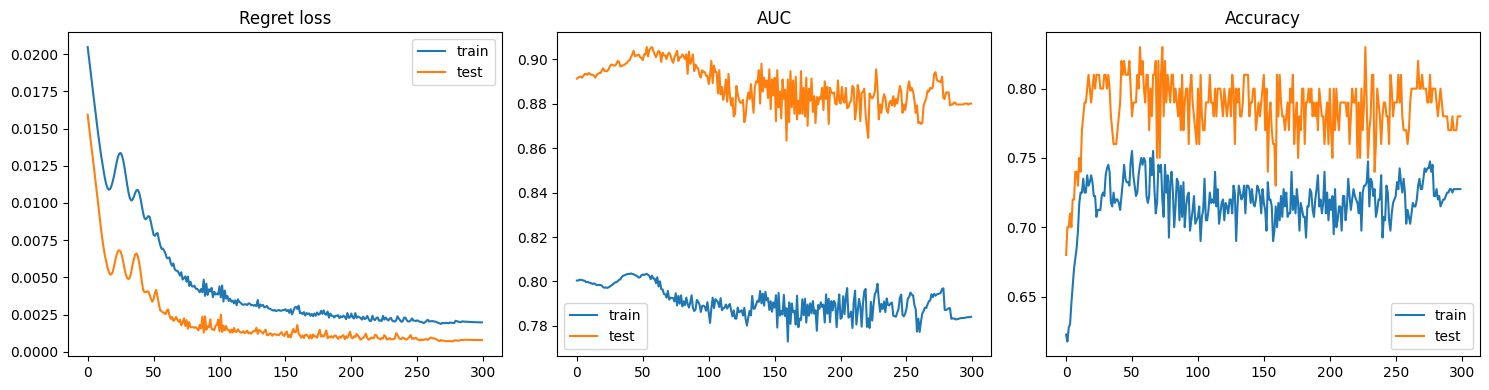

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.train_loss, label="train")
axes[0].plot(history.val_loss, label="test")
axes[0].set_title("Regret loss")
axes[0].legend()

axes[1].plot(history.train_auc, label="train")
axes[1].plot(history.val_auc, label="test")
axes[1].set_title("AUC")
axes[1].legend()

axes[2].plot(history.train_acc, label="train")
axes[2].plot(history.val_acc, label="test")
axes[2].set_title("Accuracy")
axes[2].legend()

plt.tight_layout()

## Marginal functions and derivatives (raw criterion units)
Marginals are monotone increasing in normalized preference space. In raw space this implies:
- gain criterion: increasing marginal utility, positive derivative
- cost criterion: decreasing marginal utility, negative derivative

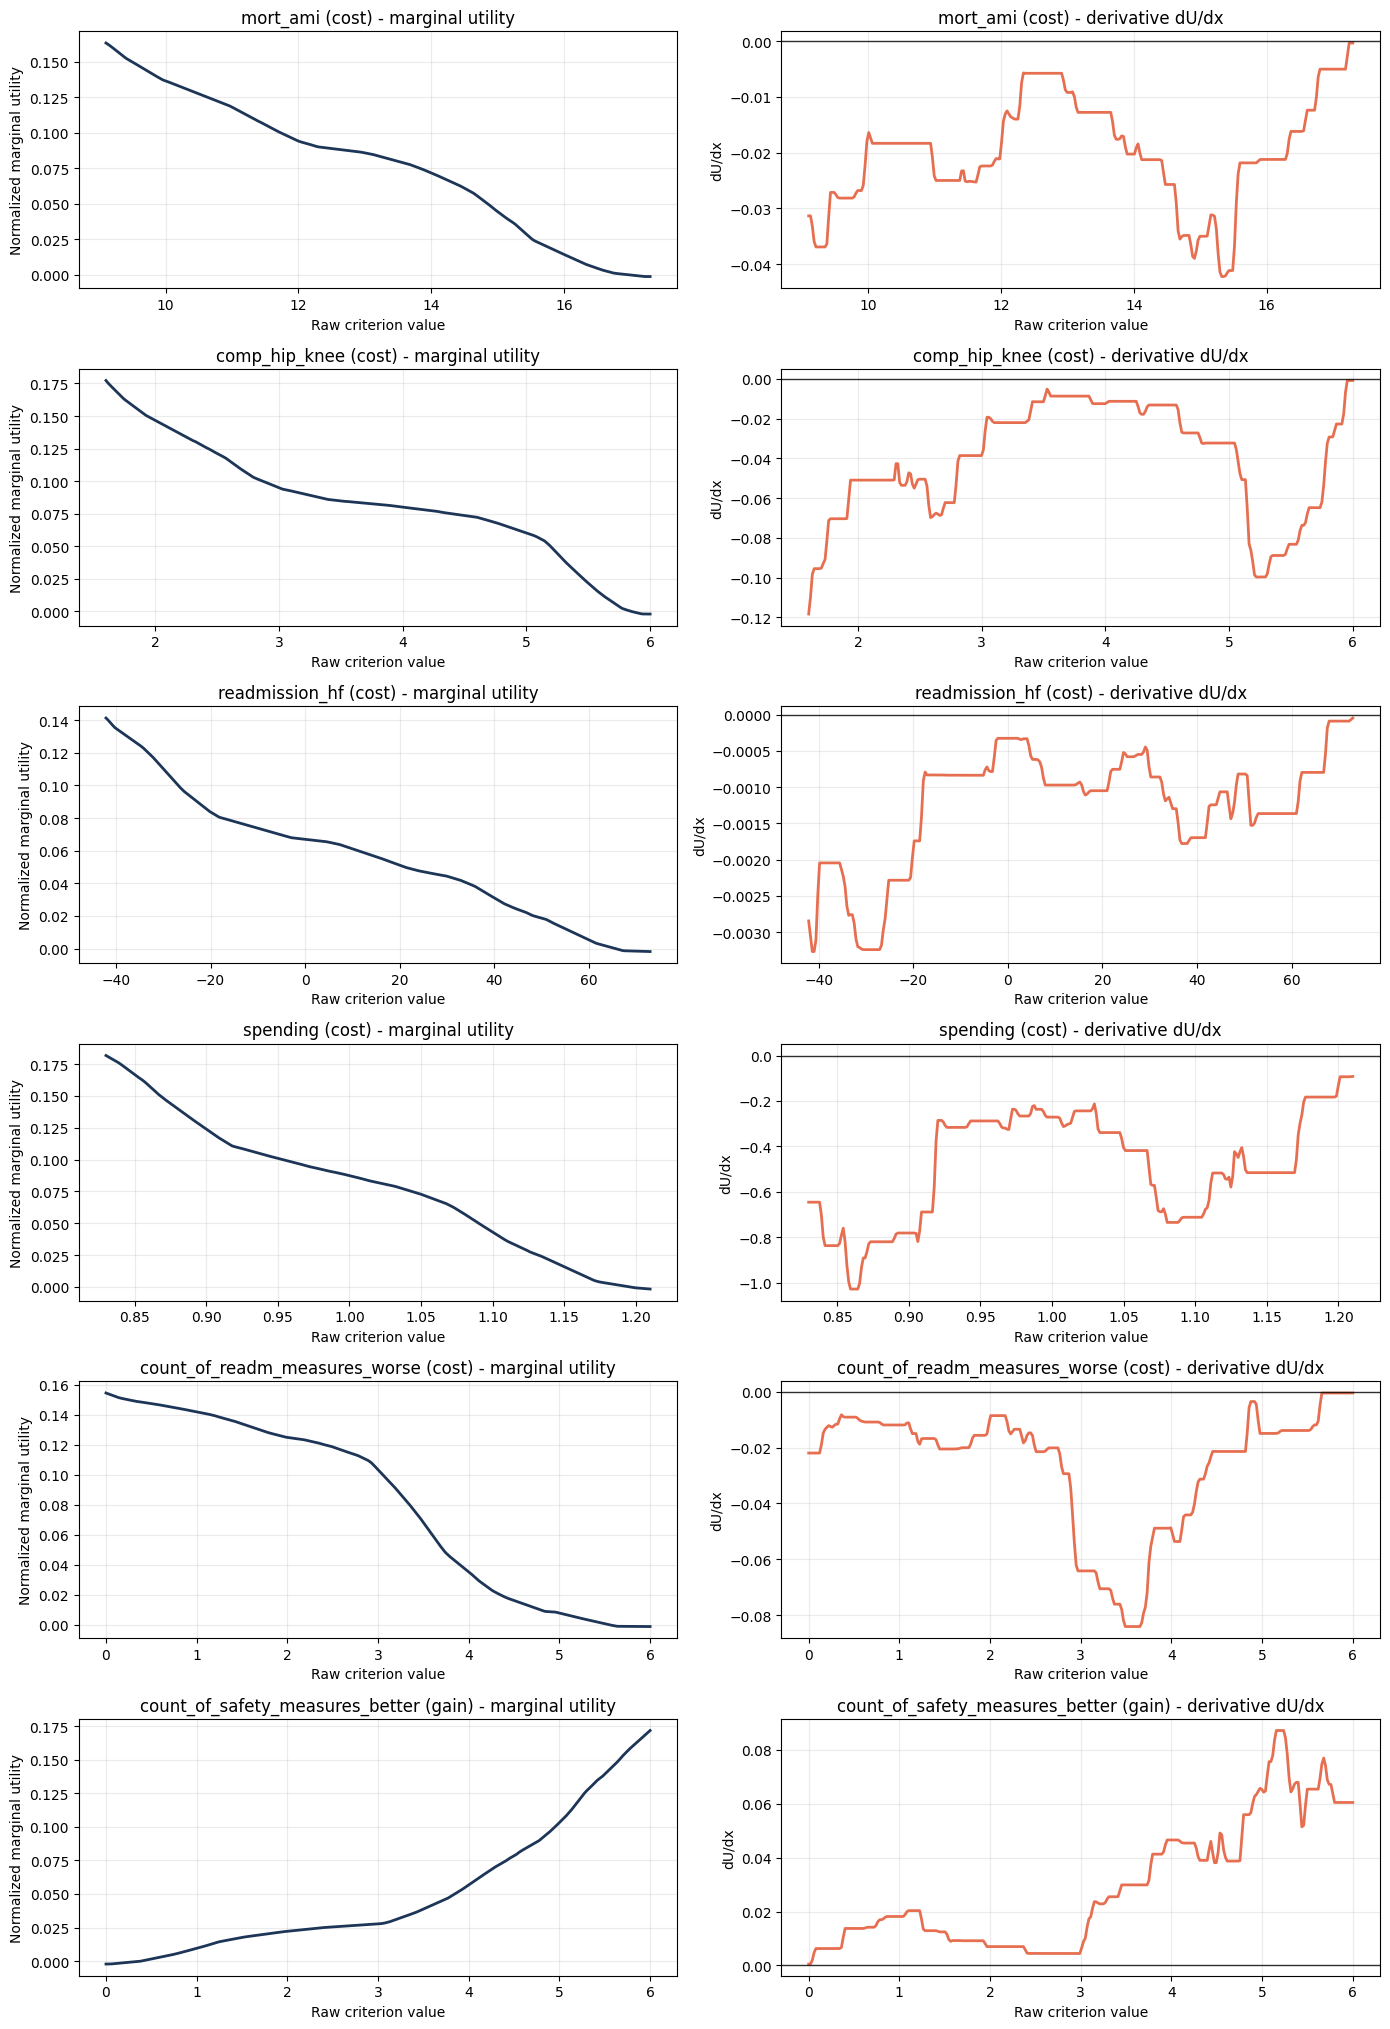

Monotonicity diagnostics in raw criterion units:


,criterion,type,expected_dUdx_sign,mean_dUdx,min_dUdx,max_dUdx,share_expected_sign
0,mort_ami,cost,negative,-0.020056,-0.042244,-0.000330,1.0
1,comp_hip_knee,cost,negative,-0.040795,-0.118361,-0.000833,1.0
2,readmission_hf,cost,negative,-0.001246,-0.003266,-0.000046,1.0
3,spending,cost,negative,-0.482153,-1.027549,-0.092239,1.0
4,count_of_readm_measures_worse,cost,negative,-0.025917,-0.084071,-0.000448,1.0
5,count_of_safety_measures_better,gain,positive,0.028981,0.000537,0.087229,1.0


In [13]:
def ann_norm_denom(model: AnnUtadis, n_criteria: int) -> float:
    with torch.no_grad():
        zero = torch.zeros((1, n_criteria), dtype=torch.float32)
        one = torch.ones((1, n_criteria), dtype=torch.float32)
        u0 = model.utility_model(zero)
        u1 = model.utility_model(one)
        denom = float((u1 - u0).item())
    return max(denom, 1e-8)


def raw_to_pref_value(raw_values: np.ndarray, feat: str) -> np.ndarray:
    lo = float(scaler.min_[feat])
    hi = float(scaler.max_[feat])
    span = hi - lo
    if span <= 1e-12:
        return np.ones_like(raw_values) if feat in cost_cols else np.zeros_like(raw_values)
    if feat in gain_cols:
        pref = (raw_values - lo) / span
    else:
        pref = 1.0 - (raw_values - lo) / span
    return np.clip(pref, 0.0, 1.0)


def marginal_curve_raw(model: AnnUtadis, feat: str, grid_size: int = 300) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    n_criteria = len(feature_cols)
    j = feature_cols.index(feat)

    x_raw = np.linspace(float(scaler.min_[feat]), float(scaler.max_[feat]), grid_size)
    x_pref = raw_to_pref_value(x_raw, feat)

    Xg = np.zeros((grid_size, n_criteria), dtype=np.float32)
    Xg[:, j] = x_pref.astype(np.float32)

    denom = ann_norm_denom(model, n_criteria)
    with torch.no_grad():
        marg = model.utility_model.monotonic_layer(torch.tensor(Xg, dtype=torch.float32))[:, j]
        marg = marg.detach().cpu().numpy() / denom

    dmarg_dx = np.gradient(marg, x_raw)
    return x_raw, marg, dmarg_dx


fig, axes = plt.subplots(len(feature_cols), 2, figsize=(14, 3.4 * len(feature_cols)))
if len(feature_cols) == 1:
    axes = np.array([axes])

diagnostics = []
for r, feat in enumerate(feature_cols):
    x_raw, marg, dmarg_dx = marginal_curve_raw(model, feat)
    nature = "gain" if feat in gain_cols else "cost"

    ax_f = axes[r, 0]
    ax_f.plot(x_raw, marg, color="#1D3557", linewidth=2)
    ax_f.set_title(f"{feat} ({nature}) - marginal utility")
    ax_f.set_xlabel("Raw criterion value")
    ax_f.set_ylabel("Normalized marginal utility")
    ax_f.grid(alpha=0.25)

    ax_d = axes[r, 1]
    ax_d.plot(x_raw, dmarg_dx, color="#E76F51", linewidth=2)
    ax_d.axhline(0.0, color="black", linewidth=1, alpha=0.8)
    ax_d.set_title(f"{feat} ({nature}) - derivative dU/dx")
    ax_d.set_xlabel("Raw criterion value")
    ax_d.set_ylabel("dU/dx")
    ax_d.grid(alpha=0.25)

    expected = "positive" if feat in gain_cols else "negative"
    sign_ok_share = float((dmarg_dx >= -1e-7).mean()) if feat in gain_cols else float((dmarg_dx <= 1e-7).mean())
    diagnostics.append({
        "criterion": feat,
        "type": nature,
        "expected_dUdx_sign": expected,
        "mean_dUdx": float(np.mean(dmarg_dx)),
        "min_dUdx": float(np.min(dmarg_dx)),
        "max_dUdx": float(np.max(dmarg_dx)),
        "share_expected_sign": sign_ok_share,
    })

plt.tight_layout()
plt.show()

diag_df = pd.DataFrame(diagnostics)
print("Monotonicity diagnostics in raw criterion units:")
display(diag_df.round(6))

## Save model

In [14]:
models_dir = project_root / "models"
bundle_path = models_dir / "ann_utadis_hospital.pt"

metadata = {
    "feature_cols": feature_cols,
    "cost_cols": cost_cols,
    "gain_cols": gain_cols,
    "target_rule": "hospital_overall_rating >= 4 -> 1 else 0",
    "scaler_min": scaler.min_,
    "scaler_max": scaler.max_,
}
save_ann_utadis_bundle(model, bundle_path, metadata)
print(f"Saved ANN-UTADIS bundle to: {bundle_path}")

Saved ANN-UTADIS bundle to: /home/marek/put/DA/mcda/models/ann_utadis_hospital.pt
